In [159]:
!pip install pandas

In [160]:
from glob import glob
import json
import matplotlib.pyplot as plt
import numpy as np
import os
from typing import List

In [161]:
RESULTS_DIR: str = "./results"

In [162]:
backend_options: List[str] = ['HRR', 'FHRR']
cleanup_methods: List[str] = ['none', 'resonator', 'modern_hopfield']
regression_methods: List[str] = ['codebook', 'neural']
seed_options: List[int] = [0, 1, 2, 3, 4, 5]

In [163]:
if not os.path.isdir(RESULTS_DIR):
    raise FileNotFoundError(f"Unable to find results directory at {RESULTS_DIR}")

In [164]:
def find_exp(root_dir: str, backend: str, cleanup: str, regression: str, seed: int):
    exp_name: str = f"{backend}_{cleanup}_{regression}_seed={seed}"
    exp_path: str = os.path.join(root_dir, exp_name)

    if not os.path.isdir(exp_path):
        raise FileNotFoundError(f"Unable to find experiment direcotry at {exp_path}")
    
    return exp_path

def load_exp(path: str, results_fname: str = "benchmark_results.json"):
    
    results_path: str = os.path.join(path, results_fname)

    if not os.path.isfile(results_path):
        raise FileNotFoundError(f"Unable to find results at {results_path}")
    
    out = {}

    with open(results_path, "r") as f:
        out = json.load(f)

    return out

In [165]:
results_dict = {}

for backend in backend_options:
    # add empty dictionary for new backend key
    if backend not in results_dict.keys():
        results_dict[backend] = {}

    for cleanup in cleanup_methods:
        # add empty dictionary for new cleanup key
        if cleanup not in results_dict[backend].keys():
            results_dict[backend][cleanup] = {}

        for regression in regression_methods:
            # add empty dictionary for new regression key
            if regression not in results_dict[backend][cleanup].keys():
                results_dict[backend][cleanup][regression] = {}
            
            for seed in seed_options:
                # load the path to the experiment and verify that it exists
                exp_path = find_exp(
                    root_dir=RESULTS_DIR,
                    backend=backend,
                    cleanup=cleanup,
                    regression=regression,
                    seed=seed
                )
                results: dict = load_exp(exp_path)
                results_dict[backend][cleanup][regression][seed] = results

print(json.dumps(results_dict, indent=4))

{
    "HRR": {
        "none": {
            "codebook": {
                "0": {
                    "backend": "HRR",
                    "resolution": 28,
                    "vector_dim": 8096,
                    "cleanup_method": "none",
                    "regression_method": "codebook",
                    "n_train": 627,
                    "n_test": 157,
                    "training_time": 0.0,
                    "positional_encoding": {
                        "total_time": 0.05116670899587916,
                        "per_sample": 8.160559648465576e-05
                    },
                    "value_encoding": {
                        "total_time": 0.030879749996529426,
                        "per_sample": 4.924999999446479e-05
                    },
                    "memory_storage": {
                        "total_time": 0.0435442080051871,
                        "per_sample": 6.944849761592839e-05
                    },
                    "global_positional_

## Calculate and Visualize Latencies

In [166]:
import numpy as np


def attach_seed_statistics(results: dict) -> dict:
    """
    Compute mean/std metrics across seeds and attach them
    to the results dictionary under a 'summary' key.
    """

    for backend, cleanup_dict in results.items():
        for cleanup_method, regression_dict in cleanup_dict.items():
            for regression_method, seed_dict in regression_dict.items():

                metrics = {
                    "positional_encoding_total_time": [],
                    "value_encoding_total_time": [],
                    "memory_storage_total_time": [],
                    "global_positional_inversion_total_time": [],
                    "global_mse": [],
                    "train_mse": [],
                    "test_mse": [],
                }

                for seed, run in seed_dict.items():

                    # Skip summary entries if function run twice
                    if seed == "summary":
                        continue

                    metrics["positional_encoding_total_time"].append(
                        run["positional_encoding"]["total_time"]
                    )

                    metrics["value_encoding_total_time"].append(
                        run["value_encoding"]["total_time"]
                    )

                    metrics["memory_storage_total_time"].append(
                        run["memory_storage"]["total_time"]
                    )

                    metrics["global_positional_inversion_total_time"].append(
                        run["global_positional_inversion"]["total_time"]
                    )

                    metrics["global_mse"].append(
                        run["global_regression"]["global_mse"]
                    )

                    metrics["train_mse"].append(
                        run["training_regression"]["train_mse"]
                    )

                    metrics["test_mse"].append(
                        run["test_regression"]["test_mse"]
                    )

                summary_mean = {k: float(np.mean(v)) for k, v in metrics.items()}
                summary_std = {k: float(np.std(v)) for k, v in metrics.items()}

                seed_dict["summary"] = {
                    "mean": summary_mean,
                    "std": summary_std,
                    "num_seeds": len(metrics["global_mse"]),
                }

    return results


In [167]:
results_dict = attach_seed_statistics(results_dict)

In [168]:
from __future__ import annotations

from collections.abc import Mapping
import pandas as pd


def flatten_pipeline_results(results: dict) -> pd.DataFrame:
    """
    Flatten nested experiment results into one row per seed.

    Expected nesting
    ----------------
    results[backend][cleanup_method][regression_method][seed] = run_dict
    """
    rows = []

    for backend, cleanup_dict in results.items():
        if not isinstance(cleanup_dict, Mapping):
            continue

        for cleanup_method, regression_dict in cleanup_dict.items():
            if not isinstance(regression_dict, Mapping):
                continue

            for regression_method, seed_dict in regression_dict.items():
                if not isinstance(seed_dict, Mapping):
                    continue

                for seed, run in seed_dict.items():
                    if not isinstance(run, Mapping):
                        continue
                    if seed == "summary":
                        continue

                    row = {
                        "backend": backend,
                        "cleanup_method": cleanup_method,
                        "regression_method": regression_method,
                        "seed": str(seed),
                        "resolution": run.get("resolution"),
                        "vector_dim": run.get("vector_dim"),
                        "n_train": run.get("n_train"),
                        "n_test": run.get("n_test"),
                        "positional_encoding": run.get("positional_encoding", {}).get("total_time", 0.0),
                        "value_encoding": run.get("value_encoding", {}).get("total_time", 0.0),
                        "memory_storage": run.get("memory_storage", {}).get("total_time", 0.0),
                        "global_positional_inversion": run.get("global_positional_inversion", {}).get("total_time", 0.0),
                        "global_cleanup": run.get("global_cleanup", {}).get("total_time", 0.0),
                        "global_regression": run.get("global_regression", {}).get("total_time", 0.0),
                        "global_mse": run.get("global_regression", {}).get("global_mse"),
                        "train_mse": run.get("training_regression", {}).get("train_mse"),
                        "test_mse": run.get("test_regression", {}).get("test_mse"),
                    }

                    row["pipeline_total"] = (
                        row["positional_encoding"]
                        + row["value_encoding"]
                        + row["memory_storage"]
                        + row["global_positional_inversion"]
                        + row["global_cleanup"]
                        + row["global_regression"]
                    )

                    rows.append(row)

    return pd.DataFrame(rows)

In [169]:
import pandas as pd


def summarize_pipeline_results(flat_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate per-seed pipeline results into mean latency per configuration.
    """
    group_cols = ["backend", "cleanup_method", "regression_method"]

    stage_cols = [
        "positional_encoding",
        "value_encoding",
        "memory_storage",
        "global_positional_inversion",
        "global_cleanup",
        "global_regression",
    ]

    summary = (
        flat_df.groupby(group_cols, as_index=False)
        .agg(
            {
                **{col: "mean" for col in stage_cols},
                "pipeline_total": ["mean", "std"],
                "test_mse": "mean",
                "seed": "count",
            }
        )
    )

    summary.columns = [
        "backend",
        "cleanup_method",
        "regression_method",
        "positional_encoding",
        "value_encoding",
        "memory_storage",
        "global_positional_inversion",
        "global_cleanup",
        "global_regression",
        "pipeline_total_mean",
        "pipeline_total_std",
        "test_mse_mean",
        "num_seeds",
    ]

    summary["label"] = (
        summary["backend"]
        + "\n"
        + summary["cleanup_method"]
        + "\n"
        + summary["regression_method"]
    )

    return summary

In [170]:
from __future__ import annotations

from pathlib import Path
from typing import Sequence

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def plot_stacked_pipeline_latency(
    summary_df: pd.DataFrame,
    *,
    sort_by: str = "pipeline_total_mean",
    ascending: bool = True,
    figsize: tuple[float, float] = (12, 6),
    title: str = "Pipeline latency breakdown",
    ylabel: str = "Mean per-sample latency (s)",
    log_scale: bool = True,
    show_total_errorbars: bool = True,
    annotate_totals: bool = False,
    save_path: str | Path | None = None,
    dpi: int = 300,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot a publication-quality stacked bar chart of mean per-sample pipeline latency.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Aggregated summary dataframe from summarize_pipeline_results().
    sort_by : str
        Column to sort bars by.
    ascending : bool
        Sorting direction.
    figsize : tuple[float, float]
        Figure size in inches.
    title : str
        Figure title.
    ylabel : str
        Y-axis label.
    log_scale : bool
        Whether to use a log scale on the y-axis.
    show_total_errorbars : bool
        Whether to overlay std-dev error bars on total latency.
    annotate_totals : bool
        Whether to annotate total latency above each bar.
    save_path : str | Path | None
        Optional path to save the figure.
    dpi : int
        Save/display DPI.

    Returns
    -------
    tuple[plt.Figure, plt.Axes]
        Figure and axes objects.
    """
    stage_cols: Sequence[str] = [
        "positional_encoding",
        "value_encoding",
        "memory_storage",
        "global_positional_inversion",
        "global_cleanup",
        "global_regression",
    ]

    stage_labels = {
        "positional_encoding": "Positional encoding",
        "value_encoding": "Value encoding",
        "memory_storage": "Memory storage",
        "global_positional_inversion": "Positional inversion",
        "global_cleanup": "Cleanup",
        "global_regression": "Regression",
    }

    plot_df = summary_df.copy().sort_values(sort_by, ascending=ascending).reset_index(drop=True)

    x = np.arange(len(plot_df))
    bottoms = np.zeros(len(plot_df), dtype=float)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    for col in stage_cols:
        values = plot_df[col].to_numpy(dtype=float)
        ax.bar(
            x,
            values,
            bottom=bottoms,
            label=stage_labels[col],
            width=0.75,
            edgecolor="black",
            linewidth=0.5,
        )
        bottoms += values

    if show_total_errorbars:
        y = plot_df["pipeline_total_mean"].to_numpy(dtype=float)
        yerr = plot_df["pipeline_total_std"].fillna(0.0).to_numpy(dtype=float)

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor="black",
            elinewidth=1.0,
            capsize=3,
            capthick=1.0,
            zorder=5,
        )

    if annotate_totals:
        totals = plot_df["pipeline_total_mean"].to_numpy(dtype=float)
        for xi, total in zip(x, totals):
            ax.text(
                xi,
                total * (1.12 if log_scale else 1.01),
                f"{total:.2e}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["label"], rotation=0, ha="center")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if log_scale:
        ax.set_yscale("log")

    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=False,
        title="Pipeline stage",
    )

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", dpi=dpi)

    return fig, ax

In [171]:
def add_compact_labels(summary_df: pd.DataFrame) -> pd.DataFrame:
    df = summary_df.copy()

    backend_map = {"HRR": "HRR", "FHRR": "FHRR"}
    cleanup_map = {
        "none": "N/A",
        "resonator": "Resonator",
        "modern_hopfield": "MHN",
    }
    regression_map = {
        "codebook": "Codebook",
        "neural": "Neural",
    }

    df["label"] = [
        f"{backend_map.get(b, b)}\n{cleanup_map.get(c, c)}\n{regression_map.get(r, r)}"
        for b, c, r in zip(df["backend"], df["cleanup_method"], df["regression_method"])
    ]
    return df

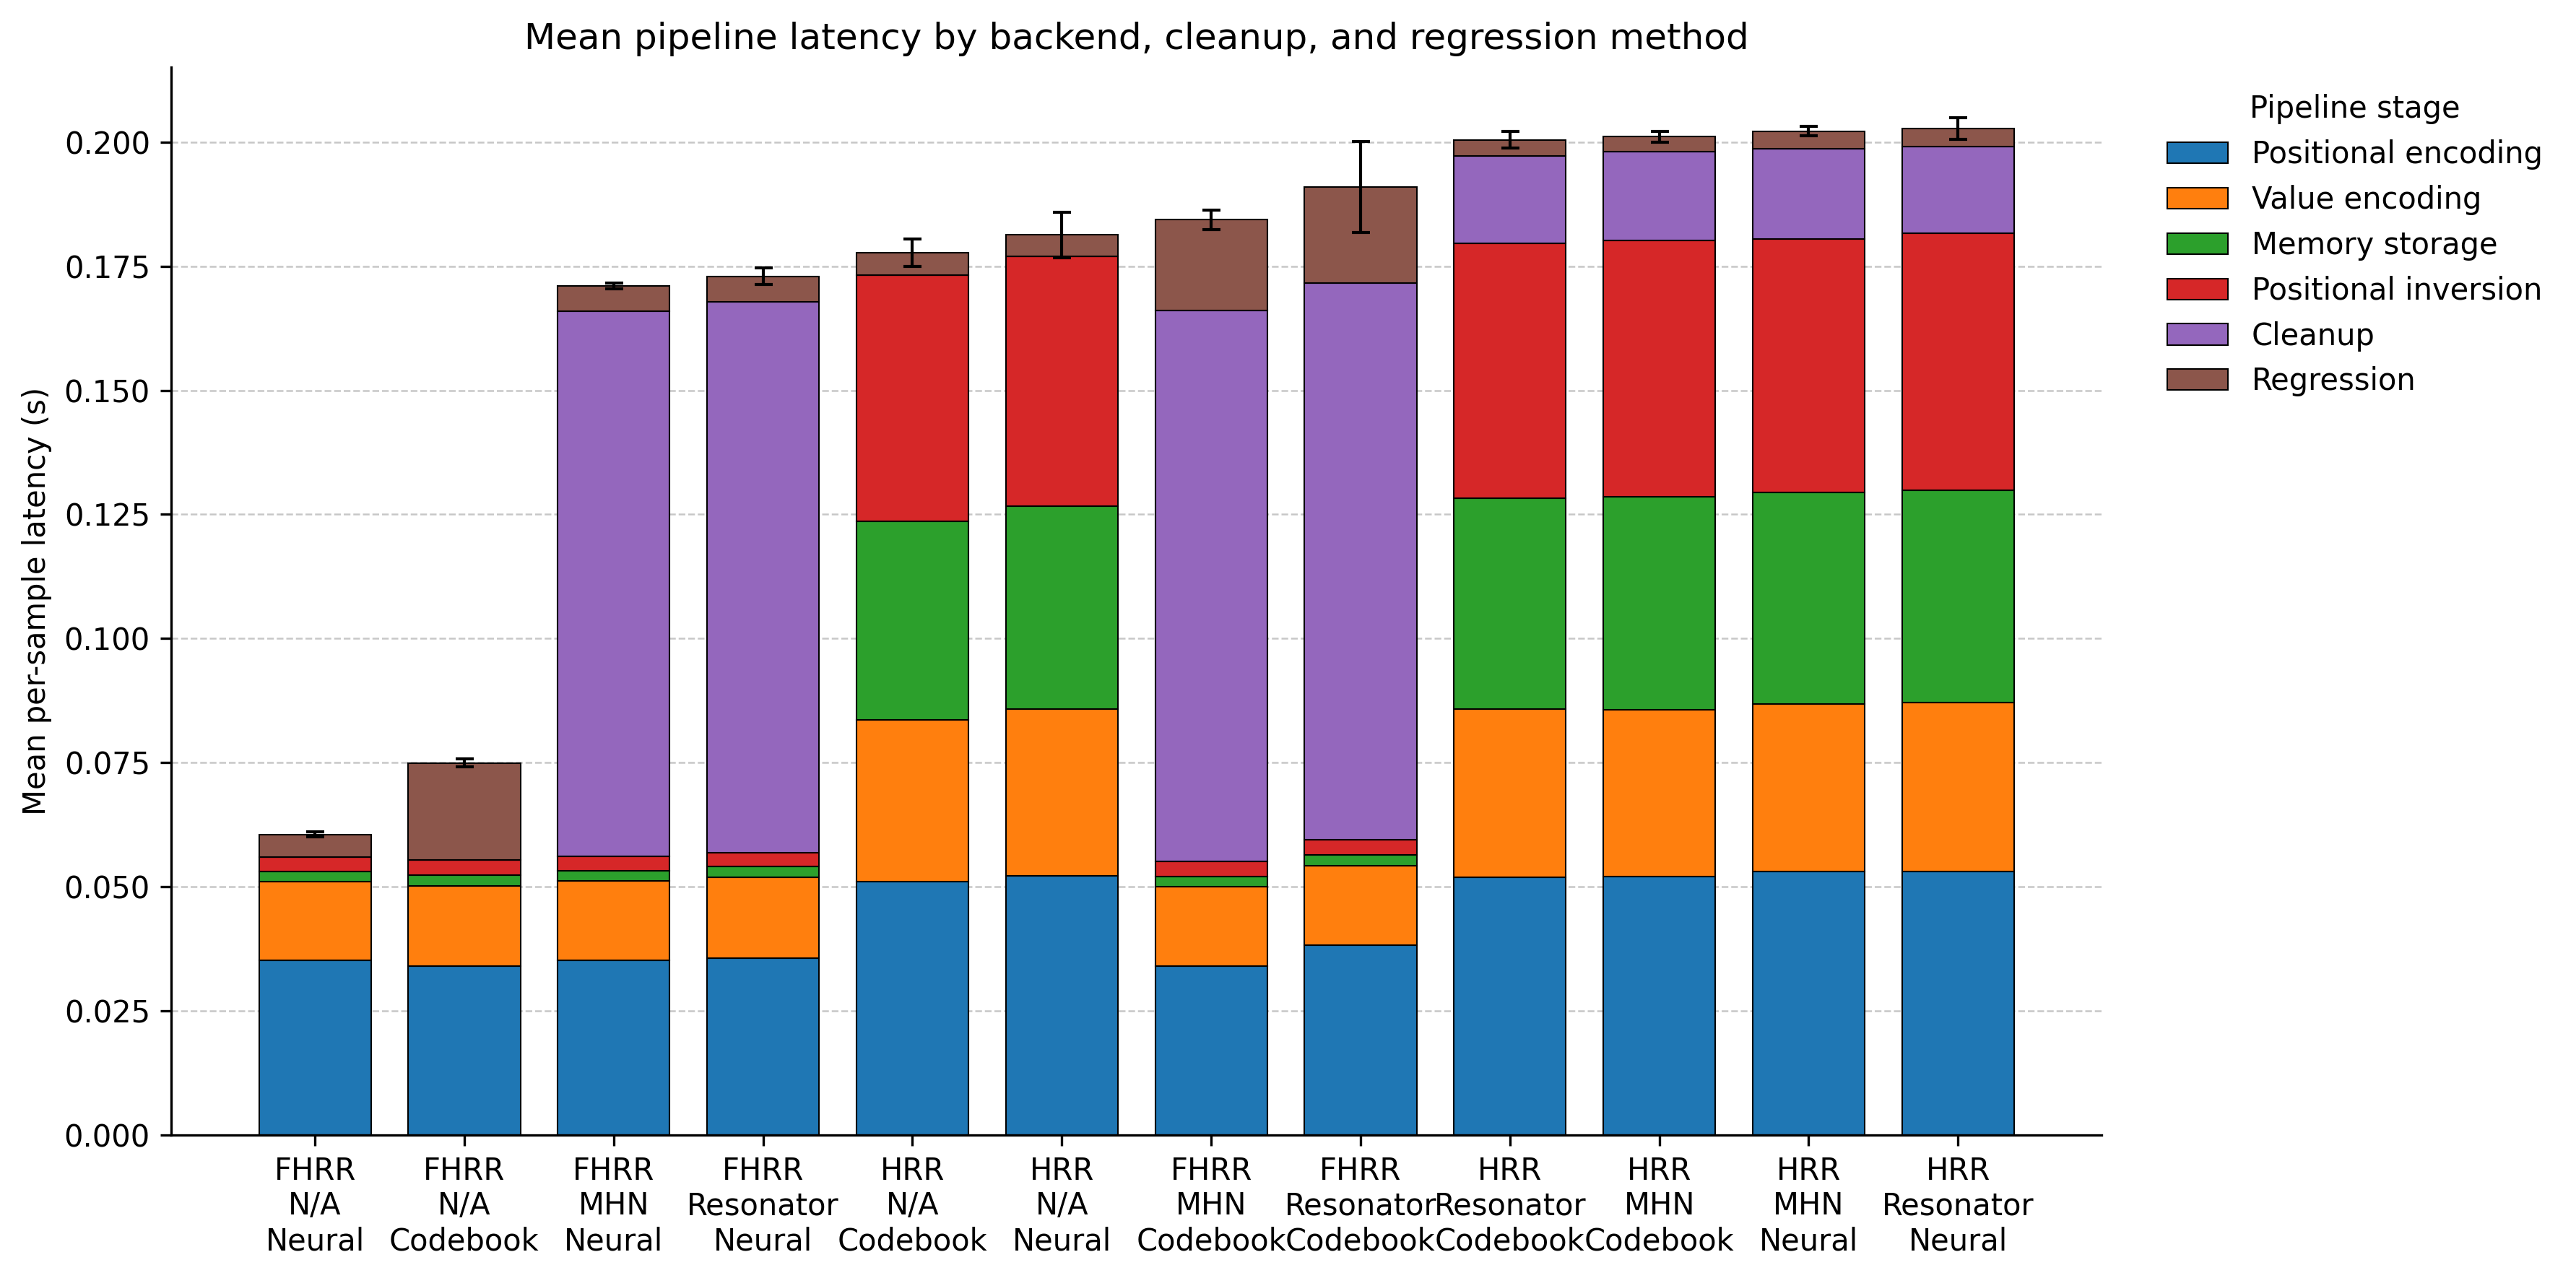

In [172]:
flat_df = flatten_pipeline_results(results_dict)
summary_df = summarize_pipeline_results(flat_df)
summary_df = add_compact_labels(summary_df)

fig, ax = plot_stacked_pipeline_latency(
    summary_df,
    sort_by="pipeline_total_mean",
    ascending=True,
    title="Mean pipeline latency by backend, cleanup, and regression method",
    save_path="figures/pipeline_latency_breakdown.png",
    log_scale=False
)
plt.show()

In [173]:
from __future__ import annotations

import numpy as np
import pandas as pd


def compute_pareto_frontier(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
) -> pd.DataFrame:
    """
    Return the Pareto-optimal rows minimizing both x_col and y_col.

    A point is Pareto-optimal if no other point has both:
    - x <= current x
    - y <= current y
    with at least one strict inequality.
    """
    work_df = df.copy().reset_index(drop=True)

    pareto_mask = np.ones(len(work_df), dtype=bool)

    x = work_df[x_col].to_numpy()
    y = work_df[y_col].to_numpy()

    for i in range(len(work_df)):
        dominated = (
            (x <= x[i]) &
            (y <= y[i]) &
            ((x < x[i]) | (y < y[i]))
        )
        dominated[i] = False
        if dominated.any():
            pareto_mask[i] = False

    pareto_df = work_df[pareto_mask].copy()
    pareto_df = pareto_df.sort_values(x_col, ascending=True).reset_index(drop=True)
    return pareto_df

In [174]:
def add_compact_labels(summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Add compact display labels for plotting.
    """
    df = summary_df.copy()

    backend_map = {
        "HRR": "HRR",
        "FHRR": "FHRR",
    }

    cleanup_map = {
        "none": "No cleanup",
        "resonator": "Resonator",
        "modern_hopfield": "Hopfield",
    }

    regression_map = {
        "codebook": "Codebook",
        "neural": "Neural",
    }

    df["compact_label"] = [
        f"{backend_map.get(b, b)} | {cleanup_map.get(c, c)} | {regression_map.get(r, r)}"
        for b, c, r in zip(df["backend"], df["cleanup_method"], df["regression_method"])
    ]

    return df

In [175]:
from __future__ import annotations

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd


def plot_pareto_latency_vs_mse(
    summary_df: pd.DataFrame,
    *,
    x_col: str = "pipeline_total_mean",
    y_col: str = "test_mse_mean",
    figsize: tuple[float, float] = (8, 6),
    title: str = "Pareto tradeoff: latency vs downstream MSE",
    xlabel: str = "Pipeline latency",
    ylabel: str = "Downstream test MSE",
    annotate: bool = True,
    annotate_frontier_only: bool = True,
    show_frontier: bool = True,
    log_x: bool = False,
    log_y: bool = False,
    save_path: str | Path | None = None,
    dpi: int = 300,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot pipeline latency versus downstream MSE and highlight the Pareto frontier.
    """
    df = summary_df.copy()

    marker_map = {
        "HRR": "o",
        "FHRR": "s",
    }

    color_map = {
        "none": "C0",
        "resonator": "C1",
        "modern_hopfield": "C2",
    }

    reg_short = {
        "codebook": "CB",
        "neural": "NN",
    }

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Plot all points
    for _, row in df.iterrows():
        ax.scatter(
            row[x_col],
            row[y_col],
            marker=marker_map.get(row["backend"], "o"),
            color=color_map.get(row["cleanup_method"], "C3"),
            s=80,
            alpha=0.9,
            edgecolors="black",
            linewidths=0.6,
            zorder=3,
        )

    # Pareto frontier
    pareto_df = compute_pareto_frontier(df, x_col=x_col, y_col=y_col)

    if show_frontier and len(pareto_df) > 0:
        ax.plot(
            pareto_df[x_col],
            pareto_df[y_col],
            linestyle="--",
            linewidth=1.5,
            color="black",
            zorder=2,
            label="Pareto frontier",
        )

        ax.scatter(
            pareto_df[x_col],
            pareto_df[y_col],
            s=140,
            facecolors="none",
            edgecolors="black",
            linewidths=1.2,
            zorder=4,
        )

    # Annotations
    if annotate:
        ann_df = pareto_df if annotate_frontier_only else df
        for _, row in ann_df.iterrows():
            text = (
                f"{row['backend']}\n"
                f"{reg_short.get(row['regression_method'], row['regression_method'])}\n"
                f"{row['cleanup_method']}"
            )
            ax.annotate(
                text,
                (row[x_col], row[y_col]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Manual legend
    backend_handles = [
        plt.Line2D(
            [0], [0],
            marker=marker,
            color="w",
            markerfacecolor="gray",
            markeredgecolor="black",
            markersize=8,
            linestyle="None",
            label=backend,
        )
        for backend, marker in marker_map.items()
    ]

    cleanup_handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=color,
            markeredgecolor="black",
            markersize=8,
            linestyle="None",
            label=cleanup,
        )
        for cleanup, color in color_map.items()
    ]

    legend1 = ax.legend(
        handles=backend_handles,
        title="Backend",
        loc="upper right",
        frameon=False,
    )
    ax.add_artist(legend1)

    # legend2 = ax.legend(
    #     handles=cleanup_handles,
    #     title="Cleanup",
    #     loc="lower left",
    #     frameon=False,
    # )

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", dpi=dpi)

    return fig, ax

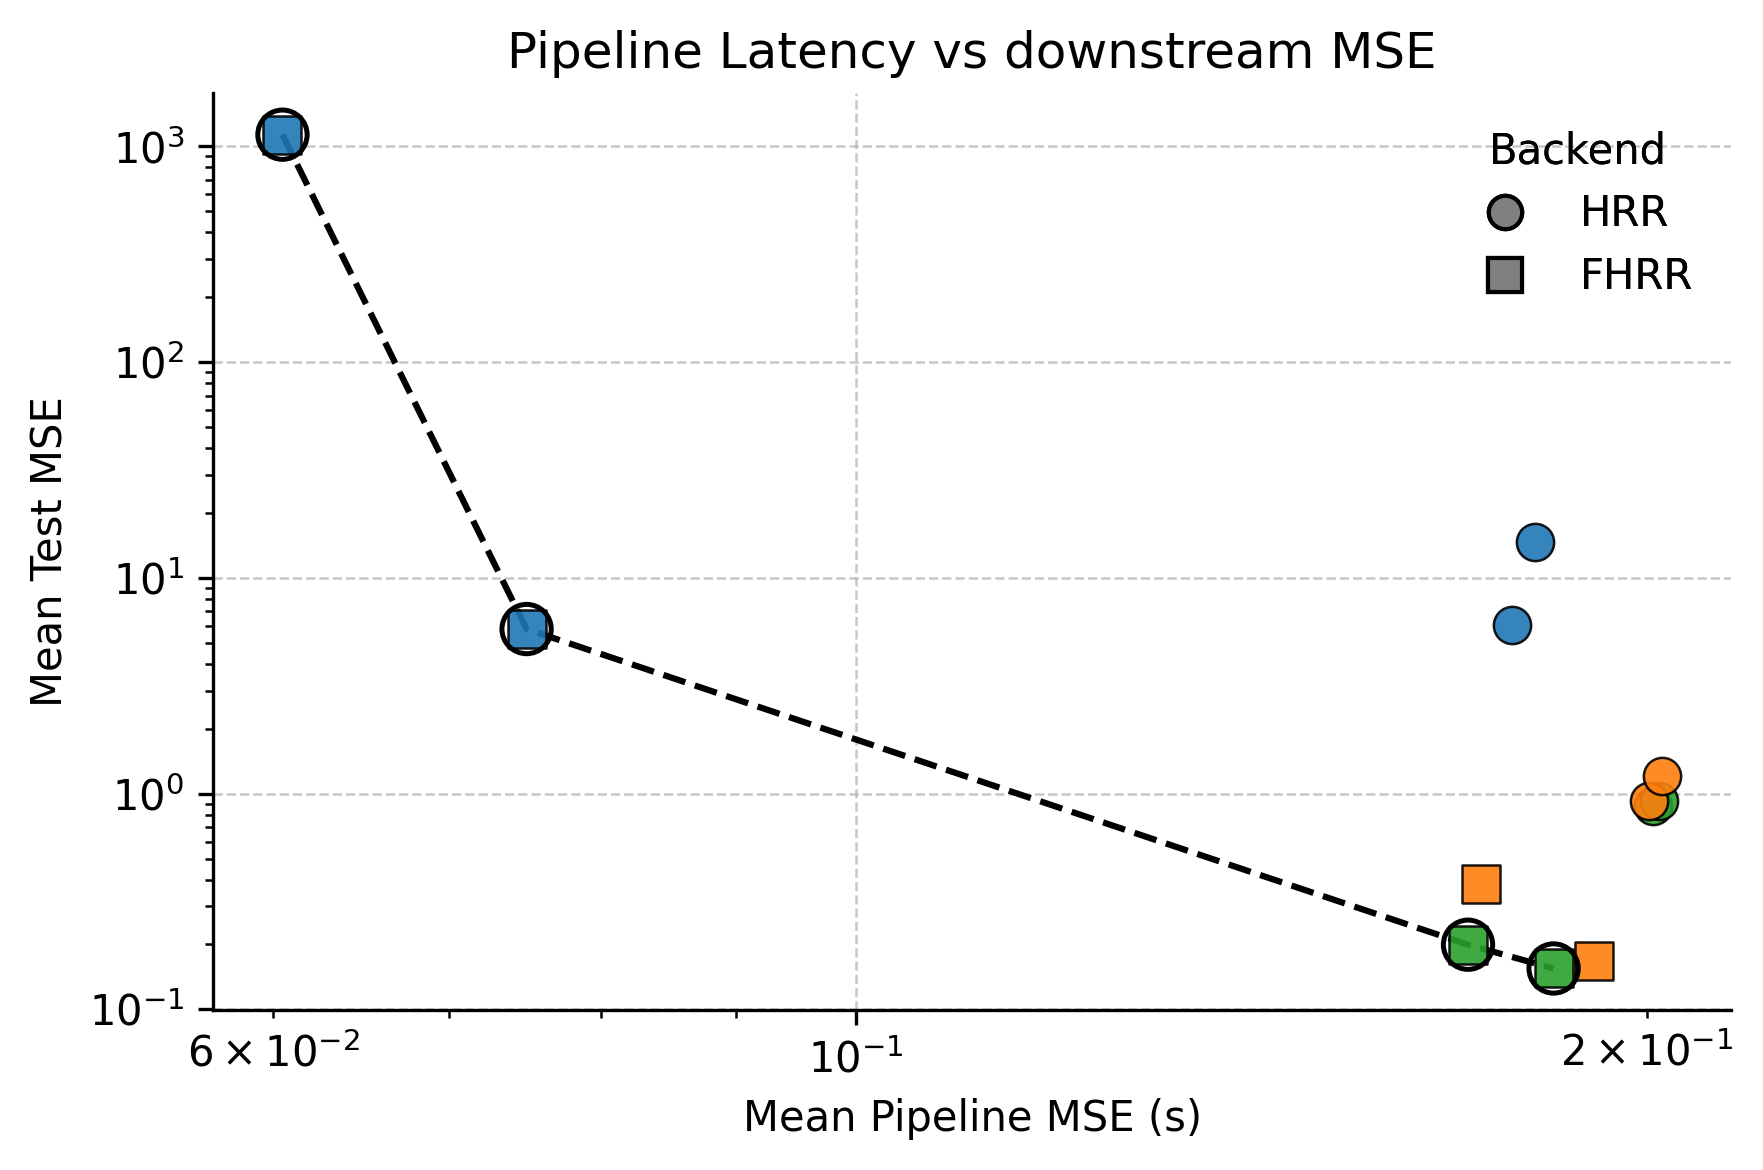

In [176]:
flat_df = flatten_pipeline_results(results_dict)

summary_df = summarize_pipeline_results(
    flat_df
)

summary_df = add_compact_labels(summary_df)

fig, ax = plot_pareto_latency_vs_mse(
    summary_df,
    x_col="pipeline_total_mean",
    y_col="test_mse_mean",
    title="Pipeline Latency vs downstream MSE",
    xlabel="Mean Pipeline MSE (s)",
    ylabel="Mean Test MSE",
    log_x=True,
    save_path="figures/pareto_per_sample_latency_vs_mse.png",
    log_y=True,
    figsize=(6, 4),
    annotate=False
)
plt.show()

In [177]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def compute_pareto_frontier(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
) -> pd.DataFrame:
    """
    Return Pareto-optimal rows minimizing both x_col and y_col.
    """
    work_df = df.copy().reset_index(drop=True)

    x = work_df[x_col].to_numpy(dtype=float)
    y = work_df[y_col].to_numpy(dtype=float)

    pareto_mask = np.ones(len(work_df), dtype=bool)

    for i in range(len(work_df)):
        dominated = (
            (x <= x[i]) &
            (y <= y[i]) &
            ((x < x[i]) | (y < y[i]))
        )
        dominated[i] = False
        if dominated.any():
            pareto_mask[i] = False

    pareto_df = work_df[pareto_mask].copy()
    pareto_df = pareto_df.sort_values(x_col, ascending=True).reset_index(drop=True)
    return pareto_df


def compute_knee_point(
    pareto_df: pd.DataFrame,
    x_col: str,
    y_col: str,
    *,
    use_log_x: bool = True,
    use_log_y: bool = True,
) -> pd.Series:
    """
    Find a knee point on the Pareto frontier using max distance from the
    line connecting the first and last Pareto points.

    Works best when Pareto points are sorted by x_col ascending.
    """
    if len(pareto_df) == 0:
        raise ValueError("pareto_df is empty")

    if len(pareto_df) == 1:
        return pareto_df.iloc[0]

    x = pareto_df[x_col].to_numpy(dtype=float)
    y = pareto_df[y_col].to_numpy(dtype=float)

    x_plot = np.log10(x) if use_log_x else x.copy()
    y_plot = np.log10(y) if use_log_y else y.copy()

    p0 = np.array([x_plot[0], y_plot[0]], dtype=float)
    p1 = np.array([x_plot[-1], y_plot[-1]], dtype=float)

    line_vec = p1 - p0
    line_norm = np.linalg.norm(line_vec)

    if line_norm == 0:
        return pareto_df.iloc[0]

    distances = []
    for xi, yi in zip(x_plot, y_plot):
        p = np.array([xi, yi], dtype=float)
        dist = np.abs(np.cross(line_vec, p - p0)) / line_norm
        distances.append(dist)

    knee_idx = int(np.argmax(distances))
    return pareto_df.iloc[knee_idx]


def add_compact_labels(summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Add compact labels for plotting/annotation.
    """
    df = summary_df.copy()

    backend_map = {
        "HRR": "HRR",
        "FHRR": "FHRR",
    }

    cleanup_map = {
        "none": "none",
        "resonator": "res",
        "modern_hopfield": "hop",
    }

    regression_map = {
        "codebook": "CB",
        "neural": "NN",
    }

    df["compact_label"] = [
        f"{backend_map.get(b, b)} / {cleanup_map.get(c, c)} / {regression_map.get(r, r)}"
        for b, c, r in zip(df["backend"], df["cleanup_method"], df["regression_method"])
    ]

    return df


def plot_pareto_latency_vs_mse_clean(
    summary_df: pd.DataFrame,
    *,
    x_col: str = "pipeline_total_mean",
    y_col: str = "test_mse_mean",
    figsize: tuple[float, float] = (9, 6),
    title: str = "Pipeline Latency vs. Test MSE",
    xlabel: str = "Mean Pipeline Latency (s)",
    ylabel: str = "Mean Test MSE",
    log_x: bool = True,
    log_y: bool = True,
    annotate_frontier_only: bool = True,
    annotate_knee_only: bool = False,
    show_frontier: bool = True,
    show_knee: bool = True,
    save_path: str | Path | None = None,
    dpi: int = 300,
) -> tuple[plt.Figure, plt.Axes, pd.DataFrame, pd.Series | None]:
    """
    Publication-style Pareto plot with:
    - gray outer marker = backend
    - colored inner marker = cleanup method
    - dashed Pareto frontier
    - knee point highlight
    - separate backend and cleanup legends
    """
    df = summary_df.copy()

    if "compact_label" not in df.columns:
        df = add_compact_labels(df)

    marker_map = {
        "HRR": "o",
        "FHRR": "s",
    }

    cleanup_color_map = {
        "none": "tab:blue",
        "resonator": "tab:orange",
        "modern_hopfield": "tab:green",
    }

    reg_short = {
        "codebook": "CB",
        "neural": "NN",
    }

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Plot all points as layered markers
    for _, row in df.iterrows():
        x = row[x_col]
        y = row[y_col]
        marker = marker_map.get(row["backend"], "o")
        color = cleanup_color_map.get(row["cleanup_method"], "tab:gray")

        # Outer gray backend marker
        ax.scatter(
            x,
            y,
            s=240,
            marker=marker,
            facecolor="lightgray",
            edgecolor="black",
            linewidth=1.2,
            zorder=2,
        )

        # Inner cleanup-colored marker
        ax.scatter(
            x,
            y,
            s=120,
            marker=marker,
            facecolor=color,
            edgecolor="none",
            alpha=0.9,
            zorder=3,
        )

    # Pareto frontier
    pareto_df = compute_pareto_frontier(df, x_col=x_col, y_col=y_col)
    knee_row = None

    if show_frontier and len(pareto_df) > 0:
        ax.plot(
            pareto_df[x_col],
            pareto_df[y_col],
            linestyle="--",
            linewidth=1.8,
            color="black",
            zorder=1,
            label="Pareto frontier",
        )

        # Outline Pareto points
        ax.scatter(
            pareto_df[x_col],
            pareto_df[y_col],
            s=340,
            facecolors="none",
            edgecolors="black",
            linewidths=1.3,
            zorder=4,
        )

        if show_knee and len(pareto_df) >= 2:
            knee_row = compute_knee_point(
                pareto_df,
                x_col=x_col,
                y_col=y_col,
                use_log_x=log_x,
                use_log_y=log_y,
            )

            # Highlight knee with star
            ax.scatter(
                knee_row[x_col],
                knee_row[y_col],
                s=260,
                marker="*",
                facecolor="gold",
                edgecolor="black",
                linewidth=1.0,
                zorder=5,
                label="Knee point",
            )

    # Annotation selection
    if annotate_knee_only and knee_row is not None:
        ann_df = pd.DataFrame([knee_row])
    elif annotate_frontier_only:
        ann_df = pareto_df
    else:
        ann_df = df

    for _, row in ann_df.iterrows():
        cleanup_short = {
            "none": "none",
            "resonator": "res",
            "modern_hopfield": "hop",
        }.get(row["cleanup_method"], row["cleanup_method"])

        label = f"{row['backend']} / {cleanup_short} / {reg_short.get(row['regression_method'], row['regression_method'])}"

        # Slightly different offset for knee label
        if knee_row is not None and row.name == knee_row.name:
            offset = (10, -14)
            bbox = dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.9)
        else:
            offset = (6, 6)
            bbox = None

        ax.annotate(
            label,
            (row[x_col], row[y_col]),
            xytext=offset,
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="bottom",
            bbox=bbox,
            zorder=6,
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # ----- Legends -----
    backend_handles = [
        plt.Line2D(
            [0], [0],
            marker=marker_map["HRR"],
            linestyle="None",
            markerfacecolor="lightgray",
            markeredgecolor="black",
            markeredgewidth=1.2,
            markersize=12,
            label="HRR",
        ),
        plt.Line2D(
            [0], [0],
            marker=marker_map["FHRR"],
            linestyle="None",
            markerfacecolor="lightgray",
            markeredgecolor="black",
            markeredgewidth=1.2,
            markersize=12,
            label="FHRR",
        ),
    ]

    cleanup_handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=cleanup_color_map["none"],
            markeredgecolor="none",
            markersize=9,
            label="None",
        ),
        plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=cleanup_color_map["resonator"],
            markeredgecolor="none",
            markersize=9,
            label="Resonator",
        ),
        plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=cleanup_color_map["modern_hopfield"],
            markeredgecolor="none",
            markersize=9,
            label="Modern Hopfield",
        ),
    ]

    legend_backend = ax.legend(
        handles=backend_handles,
        title="Backend",
        loc="upper right",
        frameon=False,
        fontsize=10,
        title_fontsize=11,
    )
    ax.add_artist(legend_backend)

    legend_cleanup = ax.legend(
        handles=cleanup_handles,
        title="Cleanup",
        loc="center right",
        bbox_to_anchor=(1.0, 0.58),
        frameon=False,
        fontsize=10,
        title_fontsize=11,
    )
    ax.add_artist(legend_cleanup)

    # Optional small legend for special markers
    extra_handles = []
    if show_frontier:
        extra_handles.append(
            plt.Line2D(
                [0], [0],
                color="black",
                linestyle="--",
                linewidth=1.8,
                label="Pareto frontier",
            )
        )
    if show_knee and knee_row is not None:
        extra_handles.append(
            plt.Line2D(
                [0], [0],
                marker="*",
                linestyle="None",
                markerfacecolor="gold",
                markeredgecolor="black",
                markersize=12,
                label="Knee point",
            )
        )

    if extra_handles:
        ax.legend(
            handles=extra_handles,
            loc="lower left",
            frameon=False,
            fontsize=10,
        )

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", dpi=dpi)

    return fig, ax, pareto_df, knee_row

/var/folders/t0/r5hw7drj6j5d16bfv65vkz5c0000gn/T/ipykernel_13664/2195312099.py:77: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(line_vec, p - p0)) / line_norm


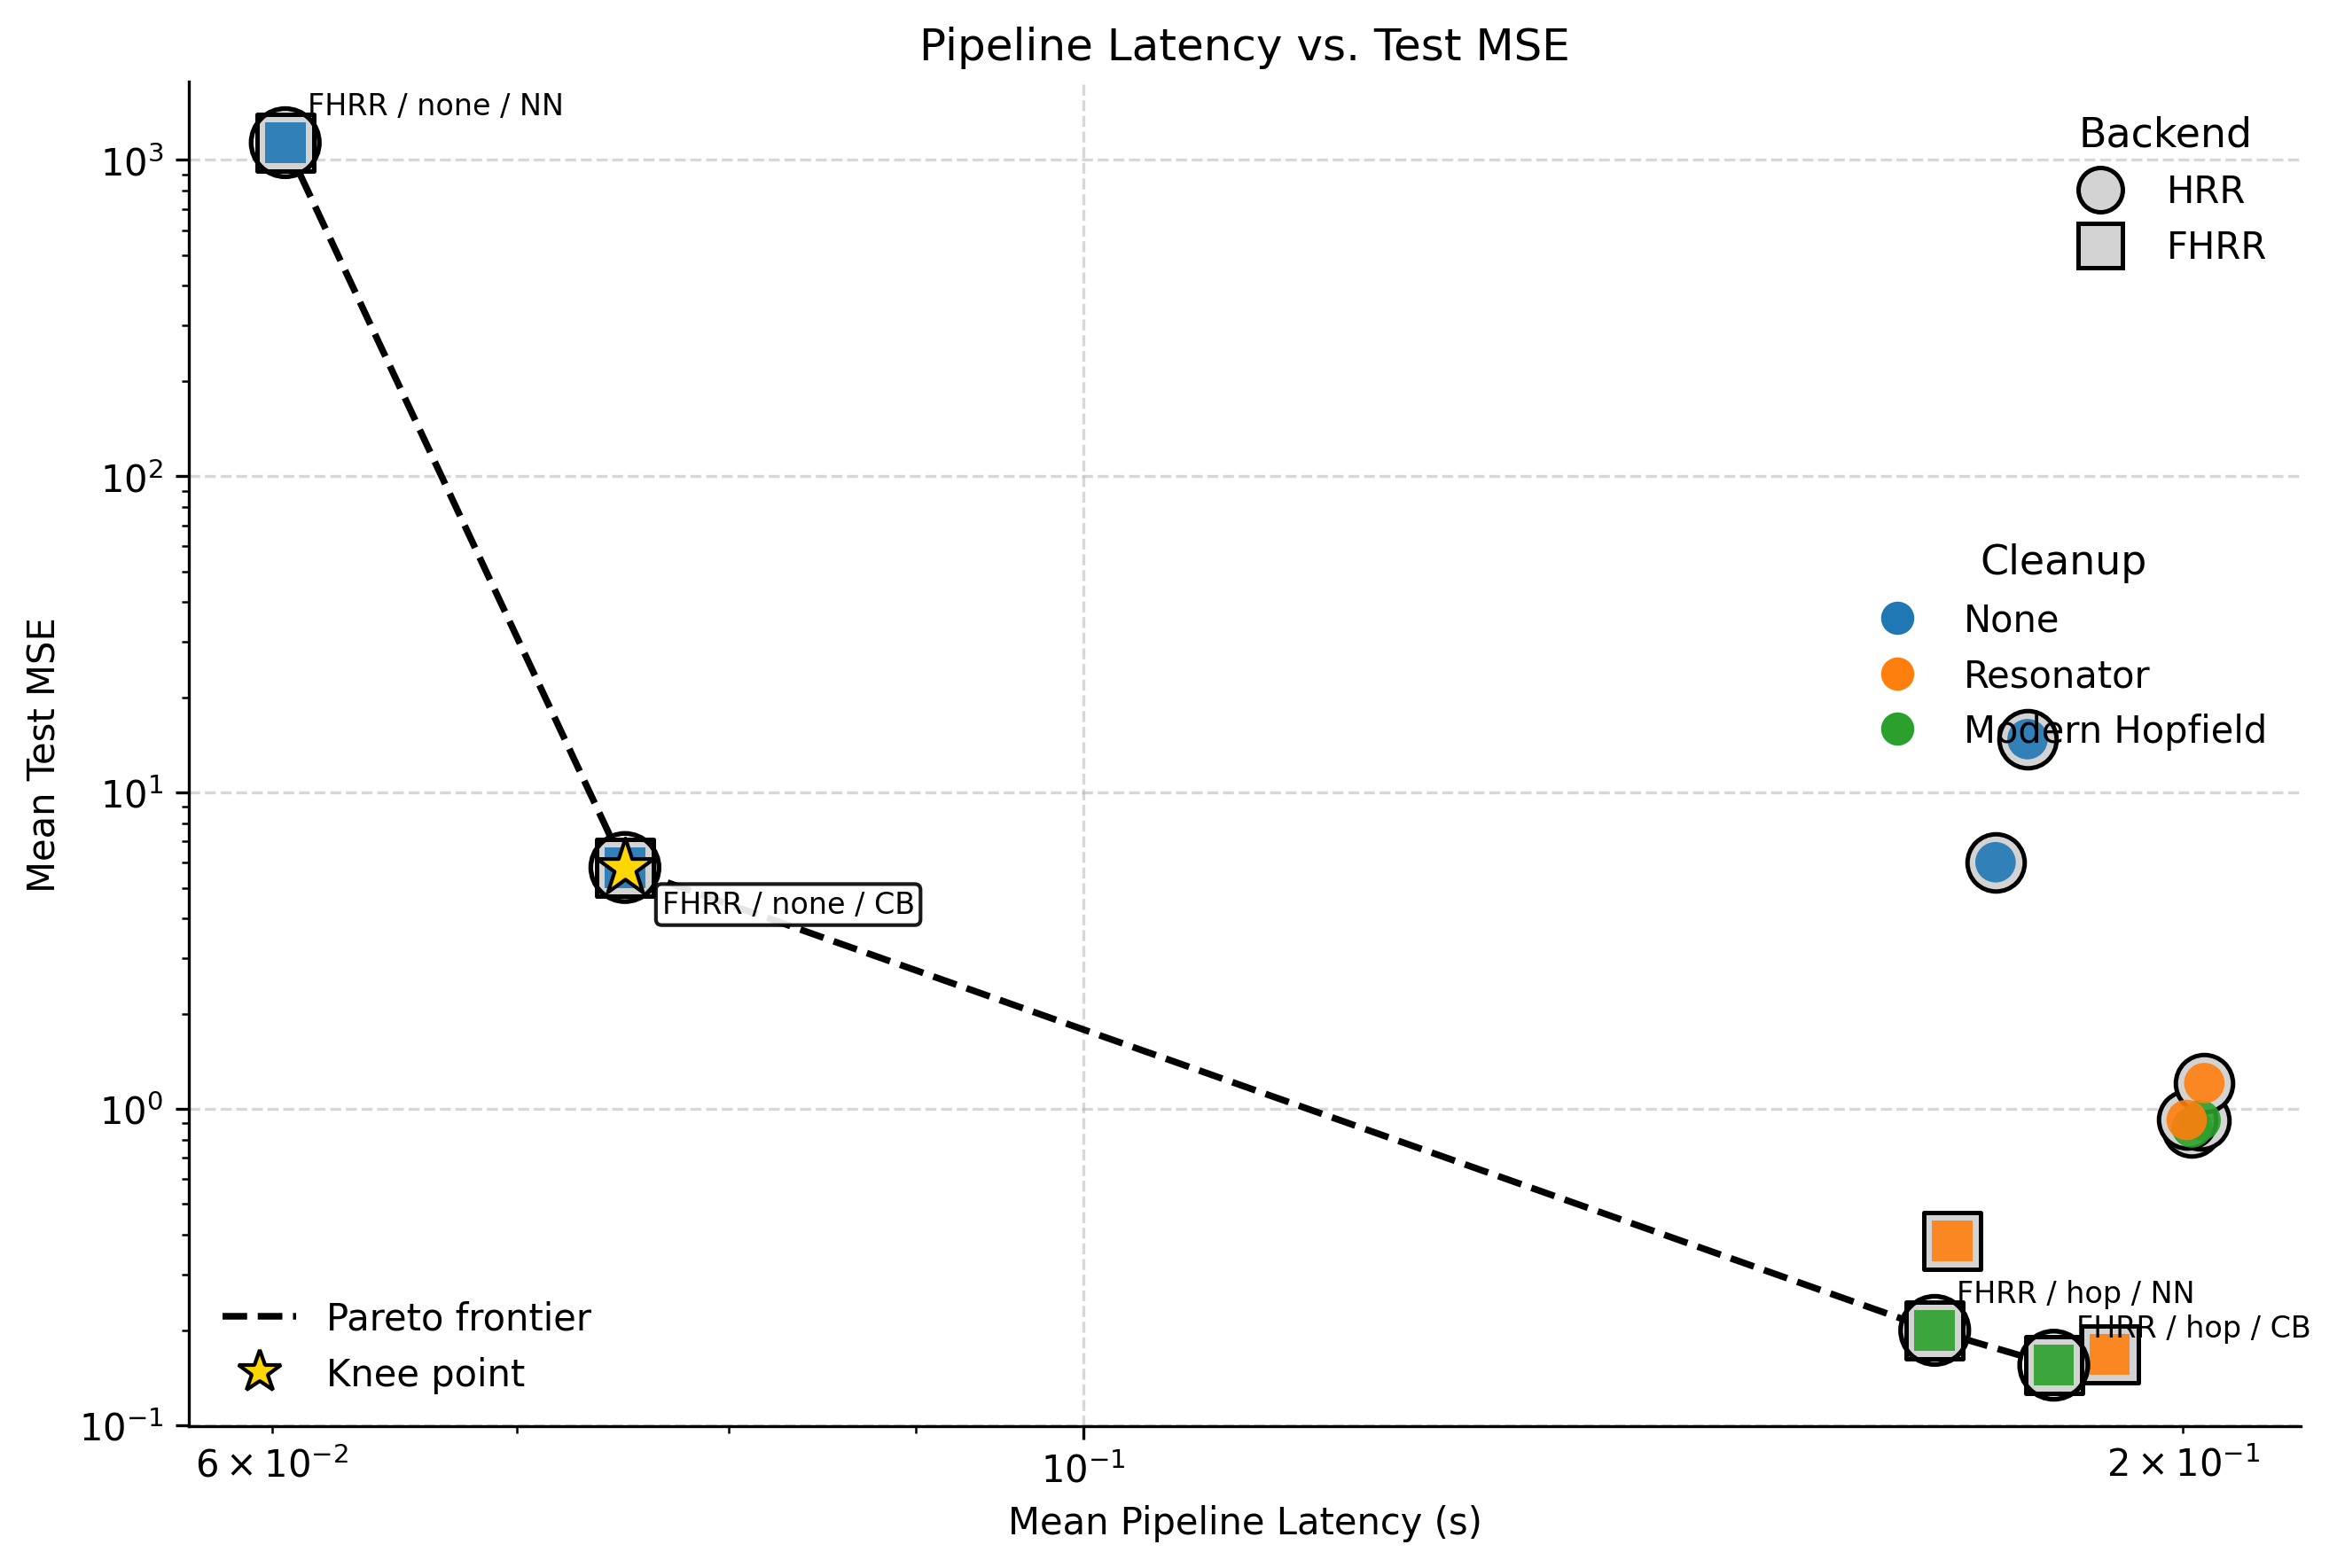

Pareto frontier:
  backend   cleanup_method regression_method  pipeline_total_mean  \
0    FHRR             none            neural             0.060498   
1    FHRR             none          codebook             0.074933   
2    FHRR  modern_hopfield            neural             0.171021   
3    FHRR  modern_hopfield          codebook             0.184344   

   test_mse_mean  
0    1133.640249  
1       5.795470  
2       0.199468  
3       0.154804  

Knee point:
backend                    FHRR
cleanup_method             none
regression_method      codebook
pipeline_total_mean    0.074933
test_mse_mean           5.79547
Name: 1, dtype: object


In [178]:
summary_df = add_compact_labels(summary_df)

fig, ax, pareto_df, knee_row = plot_pareto_latency_vs_mse_clean(
    summary_df,
    x_col="pipeline_total_mean",
    y_col="test_mse_mean",
    title="Pipeline Latency vs. Test MSE",
    xlabel="Mean Pipeline Latency (s)",
    ylabel="Mean Test MSE",
    log_x=True,
    log_y=True,
    annotate_frontier_only=True,
    annotate_knee_only=False,
    show_frontier=True,
    show_knee=True,
    save_path="figures/pareto_latency_vs_mse_clean.png",
)

plt.show()

print("Pareto frontier:")
print(pareto_df[["backend", "cleanup_method", "regression_method", "pipeline_total_mean", "test_mse_mean"]])

if knee_row is not None:
    print("\nKnee point:")
    print(knee_row[["backend", "cleanup_method", "regression_method", "pipeline_total_mean", "test_mse_mean"]])

In [179]:
def print_best_by_backend(summary_df):
    """
    Print the best configuration per backend based on lowest test MSE.
    """

    backends = summary_df["backend"].unique()

    for backend in backends:
        df_backend = summary_df[summary_df["backend"] == backend]

        best_idx = df_backend["test_mse_mean"].idxmin()
        best_row = df_backend.loc[best_idx]

        print(f"\n===== BEST {backend} CONFIGURATION (Lowest MSE) =====")

        print(f"Cleanup method     : {best_row['cleanup_method']}")
        print(f"Regression method  : {best_row['regression_method']}")
        print(f"Latency (s)        : {best_row['pipeline_total_mean']:.4f}")
        print(f"Test MSE           : {best_row['test_mse_mean']:.6f}")
        print(f"Seeds averaged     : {best_row['num_seeds']}")

        print("=====================================")

print_best_by_backend(summary_df)


===== BEST FHRR CONFIGURATION (Lowest MSE) =====
Cleanup method     : modern_hopfield
Regression method  : codebook
Latency (s)        : 0.1843
Test MSE           : 0.154804
Seeds averaged     : 6

===== BEST HRR CONFIGURATION (Lowest MSE) =====
Cleanup method     : modern_hopfield
Regression method  : codebook
Latency (s)        : 0.2011
Test MSE           : 0.873631
Seeds averaged     : 6


In [180]:
def compare_best_hrr_fhrr(summary_df):
    best_rows = {}

    for backend in ["HRR", "FHRR"]:
        df_backend = summary_df[summary_df["backend"] == backend]
        best_idx = df_backend["test_mse_mean"].idxmin()
        best_rows[backend] = df_backend.loc[best_idx]

    hrr = best_rows["HRR"]
    fhrr = best_rows["FHRR"]

    latency_ratio = fhrr["pipeline_total_mean"] / hrr["pipeline_total_mean"]
    mse_ratio = hrr["test_mse_mean"] / fhrr["test_mse_mean"]

    print("\n===== HRR vs FHRR BEST-ACCURACY COMPARISON =====")
    print(f"HRR  best: {hrr['cleanup_method']} / {hrr['regression_method']}")
    print(f"      latency = {hrr['pipeline_total_mean']:.4f} s")
    print(f"      test MSE = {hrr['test_mse_mean']:.6f}")
    print()
    print(f"FHRR best: {fhrr['cleanup_method']} / {fhrr['regression_method']}")
    print(f"      latency = {fhrr['pipeline_total_mean']:.4f} s")
    print(f"      test MSE = {fhrr['test_mse_mean']:.6f}")
    print()
    print(f"FHRR is {latency_ratio:.2f}x slower than HRR.")
    print(f"FHRR reduces MSE by {mse_ratio:.2f}x relative to HRR.")
    print("===============================================\n")

compare_best_hrr_fhrr(summary_df)


===== HRR vs FHRR BEST-ACCURACY COMPARISON =====
HRR  best: modern_hopfield / codebook
      latency = 0.2011 s
      test MSE = 0.873631

FHRR best: modern_hopfield / codebook
      latency = 0.1843 s
      test MSE = 0.154804

FHRR is 0.92x slower than HRR.
FHRR reduces MSE by 5.64x relative to HRR.



In [181]:
import json
from pathlib import Path
import numpy as np
import pandas as pd


def find_best_saved_seed_for_config(
    results_dir: str | Path,
    backend: str,
    cleanup_method: str,
    regression_method: str,
) -> Path:
    """
    Find the best saved seed directory for a given configuration based on
    the lowest test_mse stored in benchmark_results.json.
    """
    results_dir = Path(results_dir)

    candidate_dirs = sorted(
        results_dir.glob(f"{backend}_{cleanup_method}_{regression_method}_seed=*")
    )

    if not candidate_dirs:
        raise FileNotFoundError(
            f"No result directories found for "
            f"{backend} / {cleanup_method} / {regression_method}"
        )

    best_dir = None
    best_mse = np.inf

    for run_dir in candidate_dirs:
        results_json = run_dir / "benchmark_results.json"
        if not results_json.exists():
            continue

        with open(results_json, "r") as f:
            run_results = json.load(f)

        test_mse = run_results.get("test_regression", {}).get("test_mse", np.inf)

        if test_mse < best_mse:
            best_mse = test_mse
            best_dir = run_dir

    if best_dir is None:
        raise FileNotFoundError(
            f"Found directories for {backend} / {cleanup_method} / {regression_method}, "
            f"but none contained benchmark_results.json with test_mse."
        )

    return best_dir


def load_global_npz_from_run(run_dir: str | Path) -> dict:
    """
    Load global predictions and targets from a single saved run directory.
    """
    run_dir = Path(run_dir)

    global_npz = run_dir / "global_predictions.npz"
    if not global_npz.exists():
        raise FileNotFoundError(f"Missing file: {global_npz}")

    data = np.load(global_npz)

    return {
        "run_dir": run_dir,
        "predictions": data["predictions"],
        "targets": data["targets"],
    }


def load_best_hrr_fhrr_global_results(
    summary_df: pd.DataFrame,
    results_dir: str | Path = "./results",
) -> dict:
    """
    Load global predictions/targets for the best HRR and best FHRR configurations.

    Best is defined here by the lowest mean test MSE in summary_df.
    For each best configuration, the best saved seed is selected by lowest
    per-seed test_mse in benchmark_results.json.
    """
    out = {}

    for backend in ["HRR", "FHRR"]:
        df_backend = summary_df[summary_df["backend"] == backend].copy()
        if df_backend.empty:
            raise ValueError(f"No rows found in summary_df for backend={backend}")

        best_idx = df_backend["test_mse_mean"].idxmin()
        best_row = df_backend.loc[best_idx]

        cleanup_method = best_row["cleanup_method"]
        regression_method = best_row["regression_method"]

        best_run_dir = find_best_saved_seed_for_config(
            results_dir=results_dir,
            backend=backend,
            cleanup_method=cleanup_method,
            regression_method=regression_method,
        )

        loaded = load_global_npz_from_run(best_run_dir)

        out[backend] = {
            "cleanup_method": cleanup_method,
            "regression_method": regression_method,
            "summary_row": best_row,
            "run_dir": loaded["run_dir"],
            "predictions": loaded["predictions"],
            "targets": loaded["targets"],
        }

        print(f"\nLoaded best {backend} run:")
        print(f"  cleanup_method    : {cleanup_method}")
        print(f"  regression_method : {regression_method}")
        print(f"  run_dir           : {best_run_dir}")
        print(f"  predictions shape : {loaded['predictions'].shape}")
        print(f"  targets shape     : {loaded['targets'].shape}")

    return out

In [182]:
import numpy as np
import matplotlib.pyplot as plt
import math


def plot_global_comparison(hrr_preds, fhrr_preds, targets):
    """
    Plot global target, HRR reconstruction, and FHRR reconstruction side-by-side.
    """

    n = int(math.sqrt(len(targets)))

    target_grid = targets.reshape(n, n)
    hrr_grid = hrr_preds.reshape(n, n)
    fhrr_grid = fhrr_preds.reshape(n, n)

    # consistent color scale
    vmin = min(target_grid.min(), hrr_grid.min(), fhrr_grid.min())
    vmax = max(target_grid.max(), hrr_grid.max(), fhrr_grid.max())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    titles = [
        "Ground Truth Costmap",
        "HRR Reconstruction",
        "FHRR Reconstruction"
    ]

    grids = [target_grid, hrr_grid, fhrr_grid]

    for ax, grid, title in zip(axes, grids, titles):

        im = ax.imshow(
            grid,
            cmap="viridis",
            origin="lower",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    # fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)

    plt.tight_layout()
    plt.show()


Loaded best HRR run:
  cleanup_method    : modern_hopfield
  regression_method : codebook
  run_dir           : results/HRR_modern_hopfield_codebook_seed=1
  predictions shape : (784,)
  targets shape     : (784,)

Loaded best FHRR run:
  cleanup_method    : modern_hopfield
  regression_method : codebook
  run_dir           : results/FHRR_modern_hopfield_codebook_seed=0
  predictions shape : (784,)
  targets shape     : (784,)


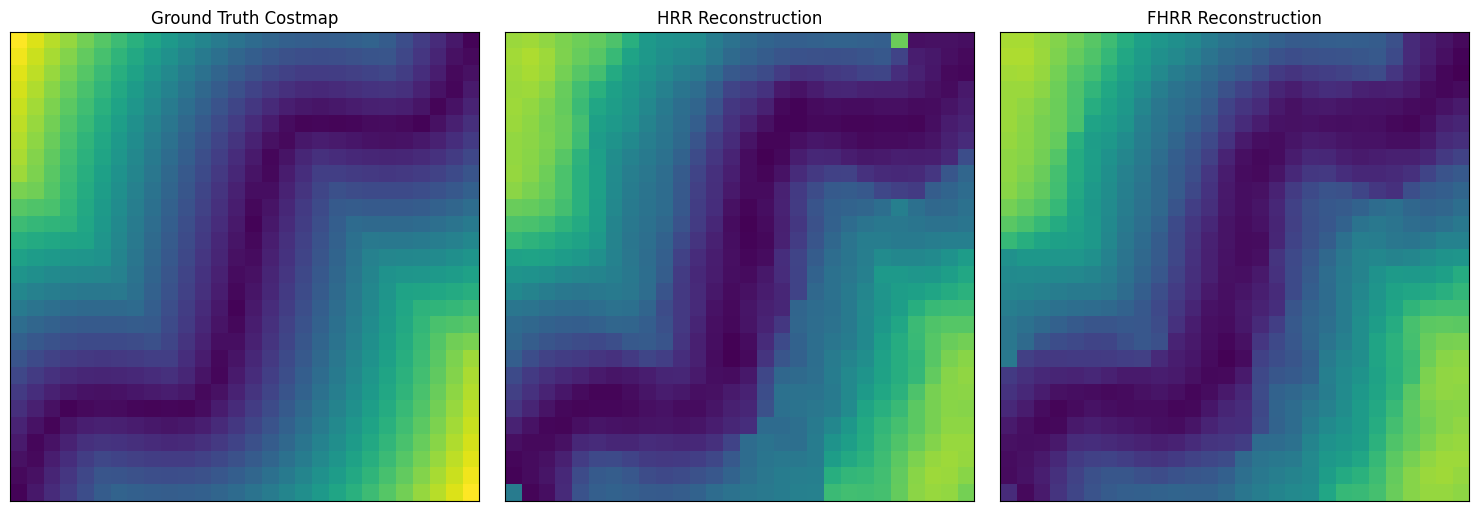

In [183]:
best_global_results = load_best_hrr_fhrr_global_results(
    summary_df,
    results_dir="./results",
)

best_hrr = best_global_results["HRR"]
best_fhrr = best_global_results["FHRR"]

hrr_preds = best_hrr["predictions"]
hrr_targets = best_hrr["targets"]

fhrr_preds = best_fhrr["predictions"]
fhrr_targets = best_fhrr["targets"]

hrr_preds = best_global_results["HRR"]["predictions"]
fhrr_preds = best_global_results["FHRR"]["predictions"]
targets = best_global_results["HRR"]["targets"]

plot_global_comparison(hrr_preds, fhrr_preds, targets)